In [27]:
import matplotlib.pyplot as plt
import sys, os

import numpy as np
import matplotlib.pyplot as plt

sys.path.append('../../official_github')
from dataset.mnist import load_mnist
from multi_layer_net_extend import MultiLayerNetExtend
from common.optimizer import SGD, Adam

In [28]:
sys.path.append('../datasets//fashion-mnist/utils/')

In [29]:
import mnist_reader
x_train, t_train = mnist_reader.load_mnist('../datasets/fashion-mnist/data/fashion/', kind='train')
x_test, t_test = mnist_reader.load_mnist('../datasets/fashion-mnist/data/fashion/', kind='t10k')

## data normalization
x_train = x_train / 255.0
x_test = x_test / 255.0 

In [30]:
print(x_train.shape)
print(np.max(x_train))
print(t_train.shape)

(60000, 784)
1.0
(60000,)


In [31]:
network_dict = {
                'sigmoid-he': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='sigmoid', weight_init_std='he'),
                'tanh': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='tanh', weight_init_std='he'),
                'relu': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='relu', weight_init_std='he'),
                'leaky': MultiLayerNetExtend(input_size=784, hidden_size_list=[100], output_size=10, activation='leaky', weight_init_std='he'),
                }

In [32]:
network_dict['relu'].params.keys()

dict_keys(['W1', 'b1', 'W2', 'b2'])

In [33]:
# 하이퍼 파라메터
iters_num = 10_000  # 반복횟수
train_size = x_train.shape[0]
batch_size = 100  # 미니배치 크기
learning_rate = 0.1
iter_per_epoch = max(train_size / batch_size, 1)

In [34]:
output_dict = {}
for key, network in network_dict.items():

    # optimizer = SGD(lr=learning_rate)
    
    output_dict[f'{key} train acc'] = []
    output_dict[f'{key} test acc'] = []
    
    print(f'=== {key} network training start ===')
    for i in range(iters_num):
        # print(i)
        # 미니배치 획득
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        # 오차역전파법으로 기울기 계산
        grad = network.gradient(x_batch, t_batch)

        # 매개변수 갱신
        for param in ('W1', 'b1', 'W2', 'b2'):
            network.params[param] -= learning_rate * grad[param]

        # 학습 경과 기록
        loss = network.loss(x_batch, t_batch)
        # print('loss:', loss)

        # 1에폭 당 정확도 계산
        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            test_acc = network.accuracy(x_test, t_test)
            output_dict[f'{key} train acc'].append(train_acc)
            output_dict[f'{key} test acc'].append(test_acc)
            print(f'--- {key} result report ---')
            print("train acc, test acc | " + str(train_acc) + ", " + str(test_acc))
        
    print('='*10)
    print('\n\n')


=== sigmoid-he network training start ===


--- sigmoid-he result report ---
train acc, test acc | 0.10616666666666667, 0.1057
--- sigmoid-he result report ---
train acc, test acc | 0.7870833333333334, 0.7746
--- sigmoid-he result report ---
train acc, test acc | 0.8165666666666667, 0.8025
--- sigmoid-he result report ---
train acc, test acc | 0.8315833333333333, 0.8175
--- sigmoid-he result report ---
train acc, test acc | 0.83885, 0.8246
--- sigmoid-he result report ---
train acc, test acc | 0.84545, 0.8329
--- sigmoid-he result report ---
train acc, test acc | 0.8502833333333333, 0.8355
--- sigmoid-he result report ---
train acc, test acc | 0.85375, 0.8343
--- sigmoid-he result report ---
train acc, test acc | 0.8579833333333333, 0.8439
--- sigmoid-he result report ---
train acc, test acc | 0.86025, 0.8449
--- sigmoid-he result report ---
train acc, test acc | 0.8619833333333333, 0.8479
--- sigmoid-he result report ---
train acc, test acc | 0.8640166666666667, 0.8486
--- sigmoid-he result report ---
train acc, test acc | 0.86

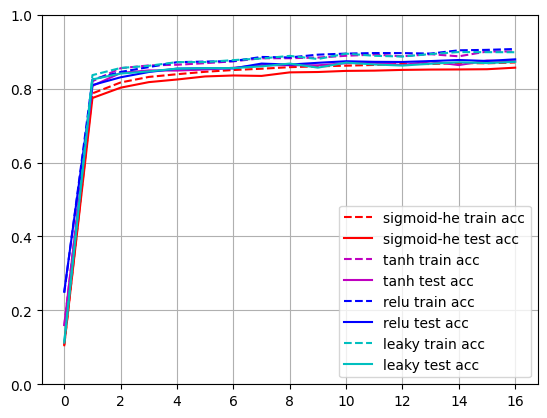

In [35]:
for k, v in output_dict.items():
    
    x = range(len(v))
    
    if k.startswith('step'):
        color_code = 'y'
    elif k.startswith('sigmoid'):
        color_code = 'r'
    elif k.startswith('tanh'):
        color_code = 'm'
    elif k.startswith('relu'):
        color_code = 'b'
    elif k.startswith('leaky'):
        color_code = 'c'

    if 'train' in k:
        linestyle = 'dashed'
    else:
        linestyle = 'solid'
    
    plt.plot(x, v, linestyle=linestyle, color=color_code, label = k)
        
plt.ylim([0.0, 1.0])
plt.legend()
plt.grid()